### Notebook Overview - Baseline Modeling

This notebook focuses on establishing a predictive baseline for the Spotify Churn Analysis. Having transformed our raw data into a high-dimensional feature set in the previous stage, we now apply statistical modeling to identify the primary drivers of user churn.

#### Objectives of this Phase

Data Integration: Load the model-ready features (X) and target (y) preserved in Parquet format.

Stratified Sampling: Implement a Stratified Train-Test Split to maintain the 3:1 class distribution identified during EDA, ensuring our evaluation is representative of the real-world imbalance.

Baseline Modeling (LASSO): Utilize Logistic Regression with L1 (LASSO) Regularization. This serves two purposes:

  Overfitting Control: Managing the 230+ polynomial interactions created in Stage 2.

  Feature Selection: Identifying which interaction terms have the most predictive power by shrinking non-essential coefficients to zero.

Use GridSearchCV to find the most optimal model parameters.

Performance Metrics: Evaluate the model using Precision, Recall, and the F1-Score, with a specific focus on our ability to correctly identify the "Churn" class (Class 1).

Next Steps: Extract the top positive and negative coefficients to translate mathematical findings into actionable business insights.

### Load the Data

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load model-ready features and target
X = pd.read_parquet('/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/data/X_final_processed.parquet')
y = pd.read_parquet('/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/data/y_final_target.parquet').squeeze()

print(f"Features loaded: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

Features loaded: (8000, 231)
Target distribution:
is_churned
0    0.741125
1    0.258875
Name: proportion, dtype: float64


### Stratified Train-Test Split

In [40]:
# Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 6400 rows
Testing set size: 1600 rows


### Baseline Logistic Regression (with LASSO)

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize Logistic Regression with L1 (LASSO) penalty
# 'liblinear' is the recommended solver for L1 on smaller/medium datasets
log_reg = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)

# Fit the model
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)

# Print results
print("--- Baseline LASSO Model Results ---")
print(classification_report(y_test, y_pred))

--- Baseline LASSO Model Results ---
              precision    recall  f1-score   support

           0       0.74      0.99      0.85      1186
           1       0.00      0.00      0.00       414

    accuracy                           0.74      1600
   macro avg       0.37      0.50      0.42      1600
weighted avg       0.55      0.74      0.63      1600



### Setup the Directory to save plots

In [1]:
import os

# Define the folder name
viz_folder = '/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizations'

# Create the folder if it doesn't already exist
if not os.path.exists(viz_folder):
    os.makedirs(viz_folder)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


#### Confusion Matrix

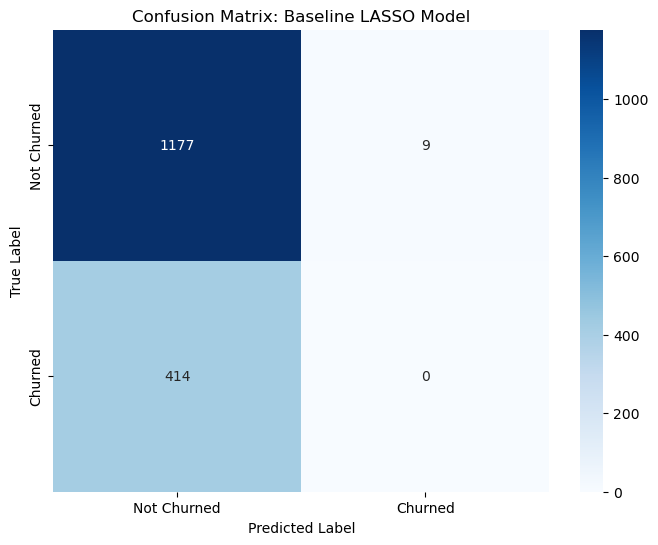

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate the confusion matrix data
cm = confusion_matrix(y_test, y_pred)

# 2. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Churned', 'Churned'], 
            yticklabels=['Not Churned', 'Churned'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Baseline LASSO Model')

# Save the plot
save_path_cm = os.path.join(viz_folder, 'baseline_confusion_matrix.png')
plt.savefig(save_path_cm, bbox_inches='tight', dpi=300)

plt.show()

The model missed all the true churned customers. This is due to class imbalance. The model learned from the dataset that is imbalanced and predicts not churned for most cases. We will adjust the model's class_weight='balanced' and add k fold validation to see their impact on the results.

### Balanced Logistic Regression (with LASSO and K-Fold CV)

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Create a Pipeline
# This ensures scaling is performed within each cross-validation fold
baseline_pipe = Pipeline([
    ('logreg', LogisticRegression(solver='liblinear', random_state=42))
])

# 2. Define the Parameter Grid
# We test different levels of L1 (LASSO) regularization and class weights
param_grid = {
    'logreg__penalty': ['l1'],
    'logreg__C': [0.01, 0.1, 1, 10],
    'logreg__class_weight': [None, 'balanced']
}

# 3. Setup Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Initialize GridSearchCV optimizing for F1-Score
grid_baseline = GridSearchCV(
    baseline_pipe, 
    param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)

# 5. Fit the Grid Search
grid_baseline.fit(X_train, y_train)

# 6. Results
print(f"Best Parameters: {grid_baseline.best_params_}")
print(f"Best Cross-Val F1 Score: {grid_baseline.best_score_:.4f}")

# Evaluate on the Test Set
y_pred_opt = grid_baseline.predict(X_test)
print("\n--- Optimized Baseline Results (Test Set) ---")
print(classification_report(y_test, y_pred_opt))

Best Parameters: {'logreg__C': 0.1, 'logreg__class_weight': 'balanced', 'logreg__penalty': 'l1'}
Best Cross-Val F1 Score: 0.3380

--- Optimized Baseline Results (Test Set) ---
              precision    recall  f1-score   support

           0       0.76      0.52      0.62      1186
           1       0.27      0.51      0.36       414

    accuracy                           0.52      1600
   macro avg       0.51      0.52      0.49      1600
weighted avg       0.63      0.52      0.55      1600



#### Confusion Matrix

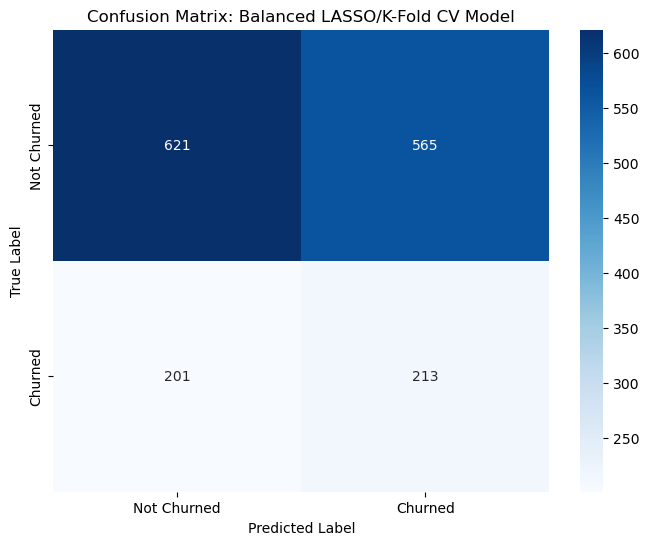

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate the confusion matrix data
cm = confusion_matrix(y_test, y_pred_opt)

# 2. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Churned', 'Churned'], 
            yticklabels=['Not Churned', 'Churned'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Balanced LASSO/K-Fold CV Model')

# Save the plot
save_path_cm = os.path.join(viz_folder, 'balanced_lasso_confusion_matrix.png')
plt.savefig(save_path_cm, bbox_inches='tight', dpi=300)

plt.show()

### **Baseline Model Performance Summary**

The confusion matrix (621, 565, 201, 213) shows the performance of the Optimized Balanced LASSO model selected with K-Fold Cross-Validation via GridSearchCV. The model has increased the identification of churners, moving away from the "majority-class" bias of the initial baseline.

True Negatives (621): Correctly identified users who remained active.

True Positives (213): Successfully captured instances of churn. This is the highest capture rate achieved thus far in the baseline phase.

False Positives (565): Active users incorrectly flagged as potential churners. This higher count reflects the model's increased sensitivity (Recall) to churn signals.

False Negatives (201): Actual churn events that the model still failed to detect.

### **Key Metrics & Insights**

Recall (~51.4%): The model now successfully identifies over half of the total churned population ($213 / 414$).

Precision (~27.4%): When the model predicts churn, it is correct in approximately 27% of cases.

Best Parameters: The grid search identified that a Lower Inverse Regularization Strength ($C=0.1$) was optimal. This indicates that a stronger LASSO penalty—which zeroes out more of the 231 engineered features—is necessary to prevent overfitting and improve generalization on the test set.

Business Trade-off: By optimizing for the F1-Score, the model balances finding enough churners to justify a retention campaign and minimizing the "waste" of sending incentives to users who are not likely to leave.

-----

### **Refining the Results**

While the feature engineering phase provided 231 features to assist the model, the current linear approach still misses roughly 49% of churners.

The next step is to investigate which specific feature interactions were assigned the highest weights by the LASSO penalty to determine the primary drivers of these predictions.

#### Key Predictors

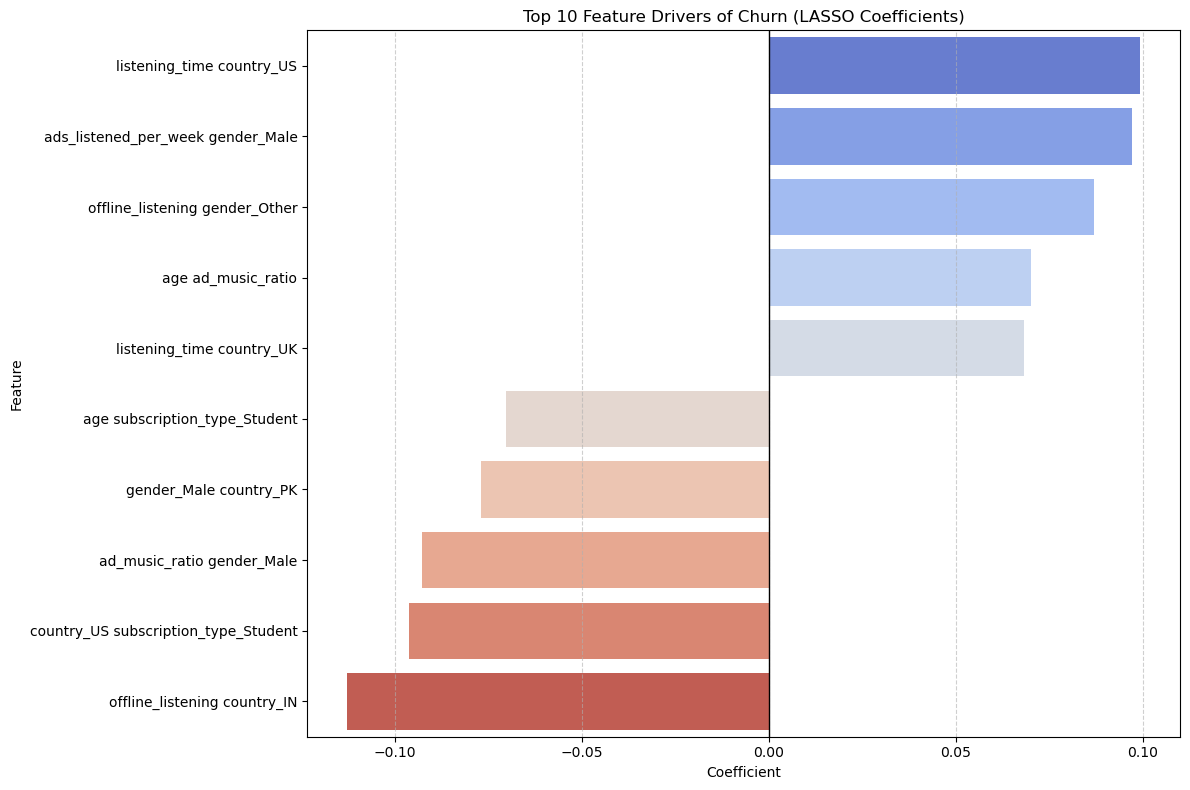

Number of features kept by LASSO: 103 out of 231


In [46]:
# Extract coefficients and visualize the Top 5 and Bottom 5 features

# 1. Access the best model (the entire pipeline)
best_pipeline = grid_baseline.best_estimator_

# 2. Extract the specific 'logreg' step from the pipeline
best_lr_model = best_pipeline.named_steps['logreg']

# 3. Get the coefficients
# .coef_[0] is used because Logistic Regression stores them in a 2D array
coefficients = best_lr_model.coef_[0]

# 4. Map coefficients to feature names for readability and store in a dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients
})

# 5. Filter for non-zero coefficients and sort by impact
# Positive coefficients increase churn probability; negative ones decrease it
# Apply the filter and sort
important_features = feature_importance[feature_importance['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

# 5. Select the Top 5 and Bottom 5 features
top_drivers = pd.concat([important_features.head(5), important_features.tail(5)])

# 6. Visualization
plt.figure(figsize=(12, 8))
sns.barplot(data=top_drivers, x='Coefficient', y='Feature', palette='coolwarm', hue='Feature')
plt.title('Top 10 Feature Drivers of Churn (LASSO Coefficients)')
plt.axvline(0, color='black', lw=1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot
save_path_drivers = os.path.join(viz_folder, 'baseline_feature_drivers.png')
plt.savefig(save_path_drivers, bbox_inches='tight', dpi=300)

plt.show()

print(f"Number of features kept by LASSO: {len(important_features)} out of {len(feature_names)}")

Positive Coefficients (Blue): Primary Churn Drivers 

These features have a direct positive correlation with churn. As these values go up, the user is more likely to leave.

listening_time country_US: This is the top driver. It suggests that in the US market, high listening time actually correlates with churn. This could indicate "heavy users" who are more likely to churn if they experience ad fatigue or are considering switching to a competitor's premium plan. **We expect high usage—like listening_time—to be a sign of a loyal customer, so this point is surprising, we will have to check other models to see if they show this feature as a driver of churn.**

ads_listened_per_week gender_Male: For male users, the sheer volume of ads is a major pain point. This identifies a specific demographic that is highly sensitive to ad interruptions.

age ad_music_ratio: This is a critical interaction. It shows that as users get older, they become much less tolerant of a high ratio of ads compared to music.

Negative Coefficients (Red): Primary Retention Drivers

These features are "anchors" that keep users subscribed. Higher values here mean the user is much more likely to stay.

country_US subscription_type_Student: Students in the US are highly loyal. This likely reflects the effectiveness of the discounted Student Plan in that specific region.

ad_music_ratio gender_Male: While males dislike a high total count of ads (the blue bar), they are actually okay if the ratio remains balanced. This suggests that as long as they get enough music for every ad played, they stay engaged.

age subscription_type_Student: Younger students (the interaction of age and student status) are very unlikely to churn, which validates the long-term value of getting users onto the platform early in life.

